# The Ho-Lee Model

## Set up

1. <font color='blue'>**Short rate dynamics:**</font>  The Ho-Lee model is given by <br><br>
$$\boxed{dr_t = \theta(t)dt + \sigma  dW^{\mathbb{Q}}_t} $$
<br>Where<br>
$$
\begin{align}
\theta(t) = \dfrac{\partial f(0,t)}{\partial t}  +\sigma^2t
\end{align}
$$

1. <font color='blue'>**Affine properties:**</font> <br>
$$\boxed{P(t,T) = A(t,T)e^{-r(t)(T-t)}}$$
<br>Where<br>
$$
\begin{align}
A(t,T) = exp\left[ ln(\dfrac{P(0,T)}{P(0,t)}) + (T-t)\dfrac{\partial f(0,t)}{\partial t} -0.5\sigma^2 t(T-t)^2  \right]
\end{align}
$$

1. <font color='blue'>**Intuition:**</font> <br>
As we can see from the figure $\theta(t)$ defines the average direction the short rate $r$ moves at time t <br>
<kbd> 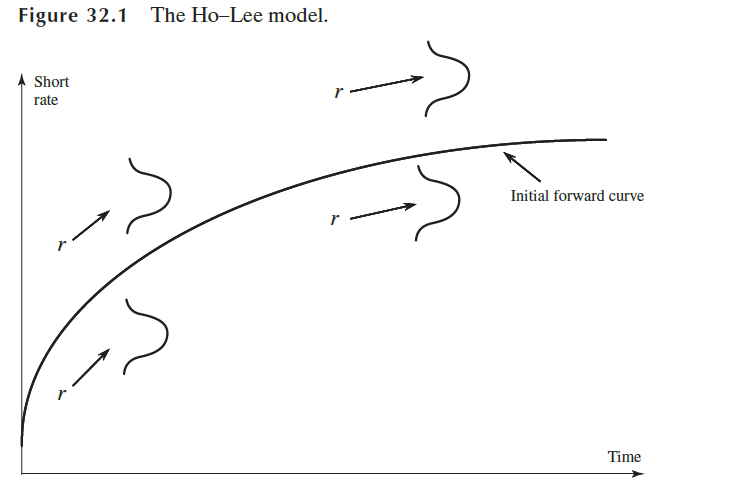</kbd>

## implementation

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import maximum, sqrt
from datetime import datetime, timedelta
from dateutil.parser import parse
from dateutil.relativedelta import relativedelta
from datetime import datetime, timedelta
from sqlalchemy import create_engine
import scipy.optimize as spop
from scipy import interpolate

def zero_coupon_to_yield(T, z):
    return -np.log(z)/T*100

# database configuration
db_name = 'PyDB_prod'
server_name = r"wbmsmc101\marketrisk"
connection_str =f"mssql+pyodbc://{server_name}/{db_name}?driver=SQL+Server+Native+Client+11.0"
conn = create_engine(connection_str).connect()

# Define the date for which we want to extra the yield curve
data_date = '09/30/2022'

# Define MC parameters
M = 10000 # number of paths
N = 250*10 # number of steps
T  = 30.0 # Horizon

# Define the sql query used to get the SDR yield curve
sql = f""" SELECT Date,Node, [t],[Rate(%)] as r FROM [PyDB_Prod].[dbo].[SDR_Curves_by_ccy]  where date = '{data_date}'  and CCY = 'SDR' Order by t """

# read the data into a dataframe
yield_curve_data = pd.read_sql(sql,conn)
yield_curve_data['Date'] = yield_curve_data.Date.apply(lambda x: x.date())

# convert the ineterat rates to zero coupon bonds 
yield_curve_data['P(0,T)'] =  np.exp(-yield_curve_data.r*yield_curve_data.t/100.0)   

# Create the yield curve function y(t) using linear interpolation
interpolator = interpolate.splrep(yield_curve_data.t, yield_curve_data.r )
y = lambda t : interpolate.splev(t,interpolator,der=0)

# define the zero coupon bond curve based on the yield curve
P0T_market = lambda T : np.exp(-y(T)/100*T)

# display some of the data
yield_curve_data.head()

,Date,Node,t,r,"P(0,T)"
0,2022-09-30,1D,0.00274,1.824031,0.999950
1,2022-09-30,3M,0.25000,2.454616,0.993882
2,2022-09-30,6M,0.50000,2.856009,0.985821
3,2022-09-30,1Y,1.00000,3.200030,0.968506
4,2022-09-30,2Y,2.00000,3.273096,0.936635


### Generate short rate paths

C:\Users\wb548956\AppData\Local\Temp/ipykernel_37472/2350609500.py:15: RuntimeWarning: invalid value encountered in true_divide
  return -np.log(z)/T*100
C:\Users\wb548956\AppData\Local\Temp/ipykernel_37472/2350609500.py:15: RuntimeWarning: invalid value encountered in true_divide
  return -np.log(z)/T*100
C:\Users\wb548956\AppData\Local\Temp/ipykernel_37472/2350609500.py:15: RuntimeWarning: invalid value encountered in true_divide
  return -np.log(z)/T*100


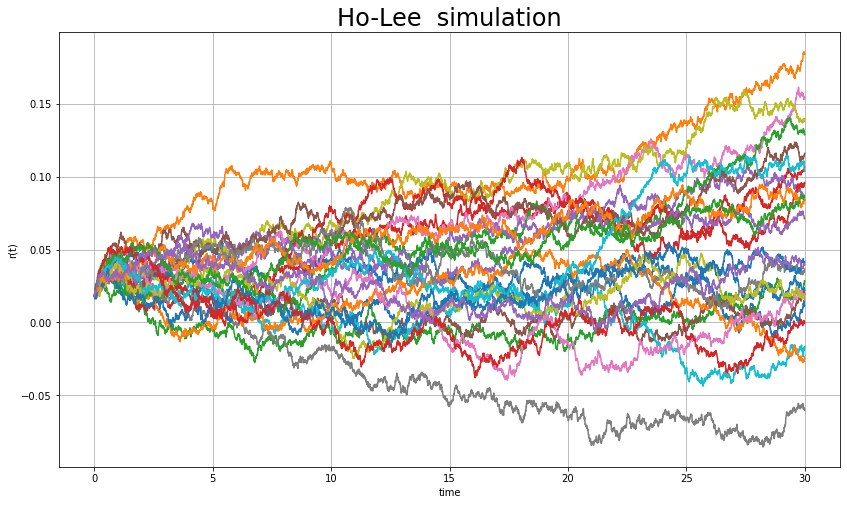

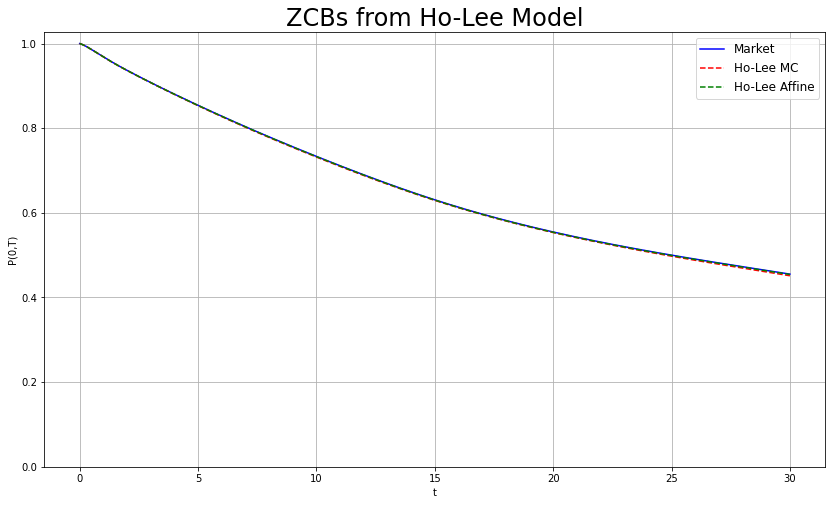

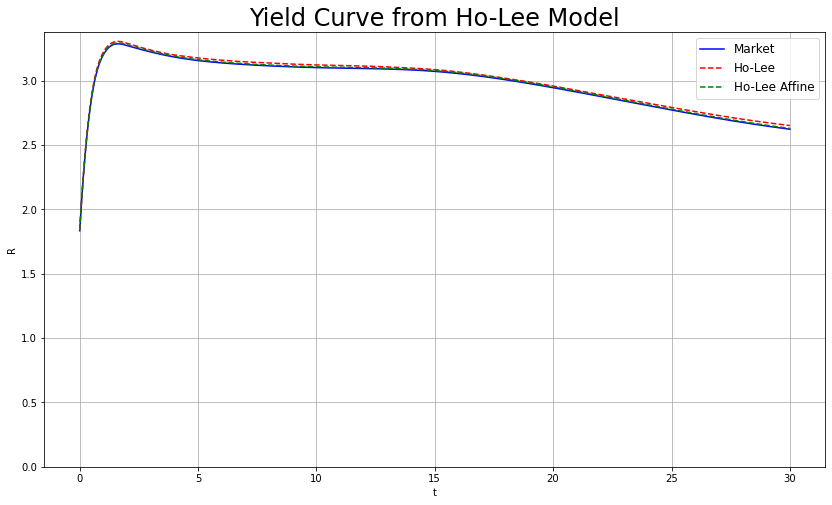

In [5]:
M = 10000 # number of paths
N = 5000 # number of steps
T  = 30
σ = 0.01
ϵ = 0.001 # used to differenciate 

P0T = lambda T: np.exp(-y(T)*T/100)  # We define a ZCB curve (obtained from the market)
f0T = lambda t: - (np.log(P0T(t+ ϵ))-np.log(P0T(t- ϵ)))/(2*ϵ)
θ  = lambda t :  (f0T(t + ϵ) - f0T(t-ϵ))/(2*ϵ) + σ**2 * t

def P0T_Ho_Lee(T , r0):
    A = np.exp( np.log(P0T(T)) + T * f0T(0) )
    return A*np.exp(-r0*T)

# Initial interest rate is a forward rate at time t->0
r0 = f0T(ϵ)

Z = np.random.normal(0.0,1.0,[M,N])
W = np.zeros([M, N+1])
R = np.zeros([M, N+1])
M_t = np.zeros([M, N+1])
M_t[:,0] = 1
R[:,0]=r0
t = np.zeros([N+1])


dt = T / float(N)


for i in range(0,N):
    W[:,i+1] = W[:, i] + Z[:,i]*sqrt(dt)
    dW = W[:,i+1] - W[:,i]
    R[:, i+1] =  R[:, i] + θ(t[i])*dt + σ*dW 
    M_t[:, i+1] = M_t[:,i] * np.exp( (R[:, i+1] + R[:, i])* 0.5 * dt)
    t[i+1] = t[i] + dt

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
plt.plot(t, np.transpose(R[0:25,:]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("r(t)");
plt.title('Ho-Lee  simulation', fontsize = 24);

P_t = np.zeros([N+1])
for i  in range(0, N+1):
    P_t[i] = np.mean(1.0/M_t[:, i])

fig = plt.figure(figsize=(14,8))
plt.grid()
plt.xlabel('t')
plt.ylabel('P(0,T)')
plt.plot(t,P0T(t),linestyle='-', color = 'b', label = 'Market')
plt.plot(t,P_t,linestyle='--', color = 'r', label = 'Ho-Lee MC')
plt.plot(t,P0T_Ho_Lee(t,r0),linestyle='--', color = 'g', label = 'Ho-Lee Affine')
plt.title('ZCBs from Ho-Lee Model',fontsize = 24)
plt.legend(fontsize = 'large')
plt.ylim(ymin=0)

fig = plt.figure(figsize=(14,8))
plt.grid()
plt.xlabel('t')
plt.ylabel('R')
plt.plot(t,zero_coupon_to_yield(t, P0T(t)),linestyle='-', color = 'b', label = 'Market')
plt.plot(t,zero_coupon_to_yield (t,P_t),linestyle='--', color = 'r', label = 'Ho-Lee')
plt.plot(t,zero_coupon_to_yield(t,P0T_Ho_Lee(t,r0)),linestyle='--', color = 'g', label = 'Ho-Lee Affine')

plt.title('Yield Curve from Ho-Lee Model',fontsize = 24)
plt.legend(fontsize = 'large')
plt.ylim(ymin=0);


### Generate the 10Y rates paths


as of 09/30/2022:
 * The 3Y 99% VaR is 6.3828485100573875
 * The Current SDR Rate is 3.1017752919635373
 * That is SDR Rate of 9.484623802020925 at the 3Y Horizon





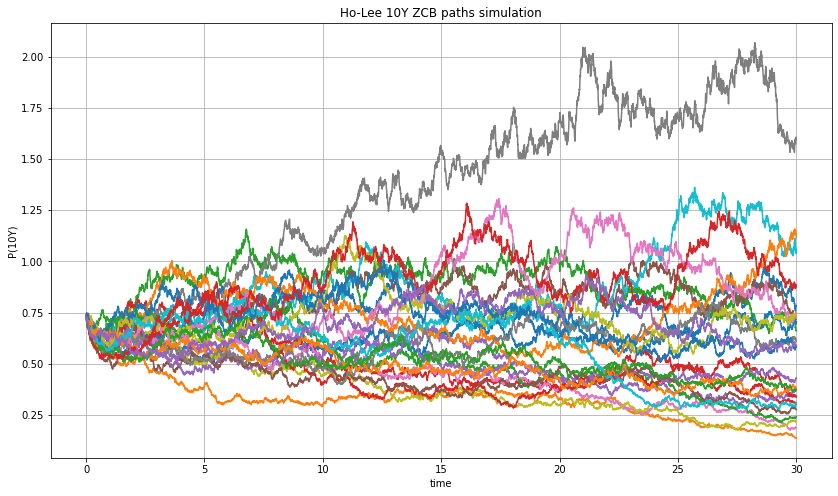

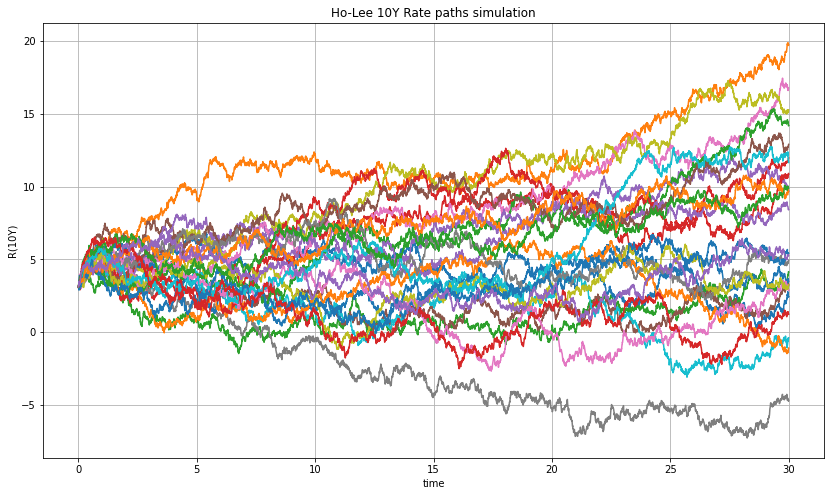

In [6]:
P_0_10 = P0T_Ho_Lee(10.0, R)
R_10Y = zero_coupon_to_yield(10,P_0_10)

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(t, np.transpose(P_0_10[:25]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("P(10Y)");
ax.set_title('Ho-Lee 10Y ZCB paths simulation');

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(t, np.transpose(R_10Y[:25]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("R(10Y)");
ax.set_title('Ho-Lee 10Y Rate paths simulation');


print(f"""
as of {data_date}:
 * The 3Y 99% VaR is {np.percentile(R_10Y[:,250*3-1], 99) - y(10)}
 * The Current SDR Rate is {y(10)}
 * That is SDR Rate of {np.percentile(R_10Y[:,250*3-1], 99)} at the 3Y Horizon


""")
